## affinity vs pred_affinity 

/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11/7e3k_H_L_C/sample_0_affinity.json
/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11/7e5y_H_L_R/sample_0_affinity.json
/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11/7akj_E_D_B/sample_0_affinity.json
/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11/7c2l_J_N_C/sample_0_affinity.json
/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11/5do2_C_D_B/sample_0_affinity.json
/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23

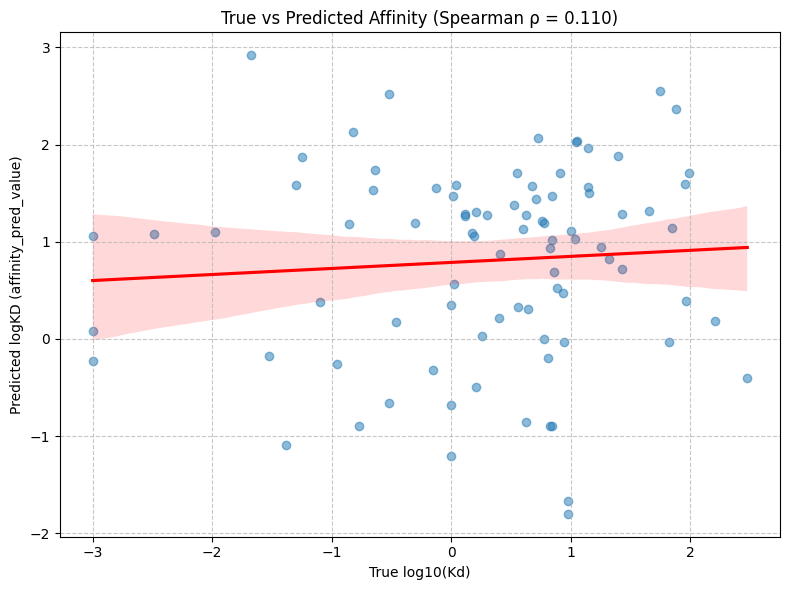

In [20]:
import os
import json
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# 1. 경로 설정
csv_path = "/home/psh/data/affinity/affinity_abrank_dms/affinity_mutation_info_clean_valid.csv"
base_dir = "/home/psh/protein-frame-flow/inference_outputs/v2.3.2.2_affinity_wo_coords/2026-01-08_15-53-52/epoch=213-step=1712/run_2026-01-09_12-23-11"

# 2. 데이터 로드
df = pd.read_csv(csv_path)

true_log_kd_list = []
pred_log_kd_list = []
found_pdb_ids = []

# 3. 데이터 매칭 및 수집
for idx, row in df.iterrows():
    # mapped_chains에서 무작위로 PDB ID 선택
    chains = str(row['mapped_chains']).split(';')
    selected_pdb = random.choice(chains).strip()
    
    # 해당 PDB ID 디렉토리 내의 JSON 파일 경로 구성
    json_file_path = os.path.join(base_dir, selected_pdb, "sample_0_affinity.json")
    
    if os.path.exists(json_file_path):
        try:
            print(f"{json_file_path}")
            with open(json_file_path, 'r') as f:
                data = json.load(f)
                pred_val = data.get('affinity_pred_value')
                
                # True Affinity_Kd에 log10 취하기 (0 이하의 값 방지 위해 필요시 처리)
                true_kd = float(row['Affinity_Kd [nM]'])
                if true_kd > 0:
                    true_log_kd = np.log10(true_kd)
                    
                    true_log_kd_list.append(true_log_kd)
                    pred_log_kd_list.append(pred_val)
                    found_pdb_ids.append(selected_pdb)
        except Exception as e:
            print(f"Error reading {json_file_path}: {e}")

# 4. 분석 및 시각화
if not true_log_kd_list:
    print("매칭되는 데이터가 없습니다. 경로와 파일명을 다시 확인해주세요.")
else:
    # Spearman 상관계수 계산
    correlation, p_value = spearmanr(true_log_kd_list, pred_log_kd_list)
    print(f"Spearman Correlation: {correlation:.4f}")
    print(f"P-value: {p_value:.4e}")

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.regplot(x=true_log_kd_list, y=pred_log_kd_list, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    
    plt.title(f'True vs Predicted Affinity (Spearman ρ = {correlation:.3f})')
    plt.xlabel('True log10(Kd)')
    plt.ylabel('Predicted logKD (affinity_pred_value)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 결과 저장 또는 출력
    plt.tight_layout()
    plt.show()
    # plt.savefig('affinity_correlation_plot.png') # 파일로 저장하려면 주석 해제